<a href="https://colab.research.google.com/github/islenaromero/connectatel-customer-analysis/blob/main/ConnectaTel_Customer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 ConnectaTel Customer Analysis

## Exploratory Data Analysis (EDA)

### Customer Behavior Analysis for a Telecommunications Company in Latin America

---

### 👩‍💻 Author

**Islena Romero**

Telecommunications Engineer | Data Analytics Portfolio

---

### 🛠 Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

---

### 📅 Analysis Period

Historical customer data through **2024**

---

### 🎯 Objective

Analyze customer behavior using service usage, subscription plans, and demographic information to identify consumption patterns, detect unusual behaviors, understand customer churn, and generate business recommendations that support customer retention and service plan optimization.

# 🎯 Business Understanding

## Background

ConnectaTel is a telecommunications company operating in Latin America. The company wants to better understand how customers use its services in order to optimize pricing strategies, improve customer retention, and enhance service offerings.

The available datasets contain customer demographics, subscribed plans, and service usage information recorded through 2024.

---

## Business Questions

This analysis seeks to answer questions such as:

- How do customers use telecommunications services?
- Are current plans aligned with customer consumption?
- Are there customers with unusual usage patterns?
- Which customer groups present different consumption behaviors?
- What business opportunities can be identified through data analysis?

---

## Expected Outcome

Provide data-driven insights that help ConnectaTel:

- Understand customer behavior.
- Improve customer retention.
- Optimize service plans.
- Support strategic business decisions.


# 📚 Import Libraries

The analysis begins by importing the Python libraries required for data manipulation, statistical analysis, and visualization.

### Libraries Used

- **Pandas:** Data manipulation and analysis.
- **NumPy:** Numerical computations.
- **Matplotlib:** Data visualization.

In [4]:
# Data manipulation n visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 📥 Data Loading

Three datasets are used throughout this project:

| Dataset | Description |
|---------|-------------|
| **plans.csv** | Service plans and pricing information. |
| **users_latam.csv** | Customer demographic information and subscription details. |
| **usage.csv** | Customer usage records including minutes and text messages. |

The datasets are loaded into pandas DataFrames to begin the exploratory analysis.

In [5]:
#  Load datasets
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

# 🔍 Dataset Overview

Before starting the analysis, it is important to understand the structure and quality of each dataset.

This step focuses on:

- Number of records
- Available variables
- Data types
- Missing values
- Overall data quality

In [6]:
# Overview
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


# 🔎 Dataset Structure Exploration

Understanding the structure of each dataset is an essential first step before conducting any analysis.

This stage focuses on evaluating the overall characteristics of the data, including the number of observations, available variables, data types, and the completeness of each dataset.

The objective is to identify potential data quality issues early and ensure that the datasets are suitable for further analysis.

### Validation Checklist

- Dataset dimensions (rows and columns)
- Variable names
- Data types
- Non-null values
- Initial data quality assessment

In [9]:
# Dataset dimensions
datasets = {
    "Plans": plans,
    "Users": users,
    "Usage": usage
}

print("📂 Dataset Dimensions\n")

for name, df in datasets.items():
    print(f"{name:<10}: {df.shape[0]} rows × {df.shape[1]} columns")

📂 Dataset Dimensions

Plans     : 2 rows × 8 columns
Users     : 4000 rows × 8 columns
Usage     : 40000 rows × 6 columns


In [10]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [11]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


# 🧹 Missing Values Analysis

Missing values can reduce the reliability of an analysis and may require data imputation or record removal.

The objective of this step is to evaluate the completeness of each dataset by identifying the number and proportion of missing values in every column.

This assessment helps determine whether additional data cleaning is necessary before proceeding with the analysis.

In [13]:
# missing values  users and usage
datasets = {
       "Users": users,
    "Usage": usage
}

for name, df in datasets.items():
    print("=" * 70)
    print(f"{name.upper()} DATASET")
    print("=" * 70)

    missing = pd.DataFrame({
        "Missing Values": df.isna().sum(),
        "Percentage (%)": (df.isna().mean() * 100).round(2)
    })

    display(missing)

    print("\n")

USERS DATASET


,Missing Values,Percentage (%)
user_id,0,0.00
first_name,0,0.00
last_name,0,0.00
age,0,0.00
city,469,11.72
reg_date,0,0.00
plan,0,0.00
churn_date,3534,88.35




USAGE DATASET


,Missing Values,Percentage (%)
id,0,0.00
user_id,0,0.00
type,0,0.00
date,50,0.12
duration,22076,55.19
length,17896,44.74


### Interpretation

The missing values analysis revealed different scenarios across the datasets.

- **`churn_date`** contains **88.35%** missing values. This is expected because the field is only populated for customers who have canceled their service. Therefore, the missing values most likely represent **active customers** rather than incomplete data. No imputation is recommended, and the column should either be retained for churn analysis or excluded if it is not required.

- **`date`** contains **50 missing values**, representing only **0.125%** of the dataset. Given the very low proportion of missing records, these observations can be removed without significantly affecting the analysis. Since this variable is essential for time-based analyses, imputing arbitrary dates is not recommended.

- **`duration`** contains **22,076 missing values (55.19%)**. Before deciding whether to remove or impute these values, it is necessary to understand the business meaning of the variable. The missing values may indicate that the field is only applicable to specific types of customer activity, such as phone calls.

- **`length`** contains **17,896 missing values (44.74%)**. Similar to `duration`, the high percentage of missing values suggests that this variable may only be relevant for certain services, such as text messages or mobile data usage. Additional investigation is required before applying any data cleaning strategy.

### Conclusion

The missing values identified in the datasets do not necessarily indicate poor data quality. Instead, several variables appear to contain **structural missing values**, meaning that the absence of information is explained by the business logic rather than by data collection errors.

Understanding the reason behind missing values is essential before deciding whether to remove, retain, or impute them. Consequently, no imputation will be performed at this stage until the context of each variable is fully understood.

# 🔎 Detection of Invalid Values and Sentinel Values

Before performing the exploratory analysis, it is important to verify whether the datasets contain invalid or sentinel values.

Sentinel values are placeholders used to represent missing or unknown information (for example: `-1`, `999`, `"Unknown"`, or empty strings). These values can distort statistical summaries and visualizations if they are not identified and handled appropriately.

This stage evaluates both numerical and categorical variables to detect potential inconsistencies that may require additional data cleaning.

In [14]:
# Numerical summary

print("="*70)
print("USERS DATASET")
print("="*70)
display(users.describe())

print("="*70)
print("USAGE DATASET")
print("="*70)
display(usage.describe())

USERS DATASET


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


USAGE DATASET


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


### Interpretation

#### Users Dataset

- The **`user_id`** column contains unique customer identifiers ranging approximately from **10,000 to 12,999**. Since this variable is an identifier, it should not be treated as a numerical variable for statistical analysis.

- The **`age`** column includes **negative values**, which are not valid for customer ages. These records likely represent data entry errors or invalid values and should be investigated before continuing the analysis. The maximum observed age is **79 years**, which falls within a realistic range.

#### Usage Dataset

- The **`id`** and **`user_id`** columns are unique identifiers rather than analytical variables. Their numerical values do not carry quantitative meaning and should be excluded from statistical analyses.

- The **`duration`** variable ranges from **0 to 120 minutes**, with an average of **5.20 minutes**. The maximum value (120) is considerably higher than the 75th percentile (6.99), suggesting the presence of potential outliers that should be examined during the outlier analysis.

- The **`length`** variable ranges from **0 to 1,490 units**, with an average value of **52.13**. Since the maximum value is substantially higher than the 75th percentile (64), this variable also appears to contain potential outliers that require further investigation.
### Conclusion

The review of numerical variables identified two important findings:

1. The **`age`** variable contains invalid negative values that must be addressed during the data cleaning process.

2. The **`duration`** and **`length`** variables exhibit unusually large maximum values compared to their upper quartiles. These observations may represent legitimate high-usage customers or statistical outliers, and they will be evaluated in detail during the outlier detection stage.

No evidence of invalid identifier values was found, and identifier columns will be excluded from subsequent statistical analyses.

In [15]:
# categorical variables
columnas_user = ['city', 'plan']

for col in columnas_user:
        print(f"\nColumna: {col}")
        print(users[col].value_counts(dropna=False))
        print("Valores únicos:", users[col].nunique(dropna=True))


Columna: city
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64
Valores únicos: 7

Columna: plan
plan
Basico     2595
Premium    1405
Name: count, dtype: int64
Valores únicos: 2


In [16]:
# categorical variables
usage['type'].value_counts(dropna=False)

,count
type,
text,22092
call,17908


### Interpretation

#### Users Dataset

The categorical variables were reviewed to identify invalid categories, inconsistent labels, and potential sentinel values.

- The **`city`** variable contains seven valid cities; however, two data quality issues were identified:
  - **469 missing values (`NaN`)**, indicating that the customer's city was not recorded.
  - **96 records with the value `"?"`**, which appears to be a placeholder (sentinel value) representing unknown or unavailable information rather than a valid city.

  Before performing analyses by geographic location, these records should be reviewed and handled appropriately.

- The **`plan`** variable contains only two valid categories: **Basic** and **Premium**. No unexpected categories or invalid values were identified, indicating that this variable is consistent and ready for analysis.

#### Usage Dataset

- The **`type`** variable contains two expected categories:
  - **call**
  - **text**

  No missing values or unexpected categories were detected, suggesting that this variable has good data quality and can be used directly in the analysis.
  ### Conclusion

The categorical data review identified one relevant data quality issue.

The **`city`** variable contains both missing values and the placeholder value `"?"`, which should be treated as missing or unknown information before conducting any geographic analysis.

The remaining categorical variables (`plan` and `type`) are consistent, contain only valid categories, and do not require additional cleaning.


### Data Cleaning Strategy

Based on the data quality assessment, the following cleaning actions are proposed:

#### `city`

- The variable contains both missing values (`NaN`) and the placeholder value `"?"`, which represents unknown city information.
- Replace `"?"` with `NaN` to standardize missing values.
- Later, evaluate whether to:
  - keep the missing values,
  - impute them as `"Unknown"` if required for categorical analysis,
  - or exclude them depending on the analysis objective.

---

#### `age`

- The variable contains the invalid value **`-999`**, which is clearly outside the valid range for customer age.
- Replace `-999` with `NaN`.
- Evaluate the number of affected records before deciding whether to:
  - impute the missing values using the median age,
  - or remove those observations if their number is negligible.

---

#### `churn_date`

- This variable contains a high proportion of missing values.
- The missing values appear to have a business meaning rather than representing poor data quality, since they likely correspond to customers who have **not canceled** their service.
- Therefore, the missing values should be preserved.
- If required, create a derived variable such as `is_churned` to explicitly identify whether a customer has churned.

# 📅 Date Validation and Standardization

Date variables are essential for time-based analyses such as customer registration trends, service usage patterns, and churn analysis.

Before performing any temporal analysis, it is necessary to ensure that all date columns are stored using the correct data type and that they contain valid calendar dates.

This validation includes:

- Converting date variables to the appropriate datetime format.
- Handling invalid date formats safely.
- Reviewing the distribution of years.
- Identifying impossible dates (e.g., future dates beyond 2024).

In [17]:
# Convert date columns safely
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")

In [18]:
print("Registration years")
display(users["reg_date"].dt.year.value_counts().sort_index())

print("\nUsage years")
display(usage["date"].dt.year.value_counts().sort_index())

Registration years


,count
reg_date,
2022,1314
2023,1316
2024,1330
2026,40



Usage years


,count
date,
2024.0,39950


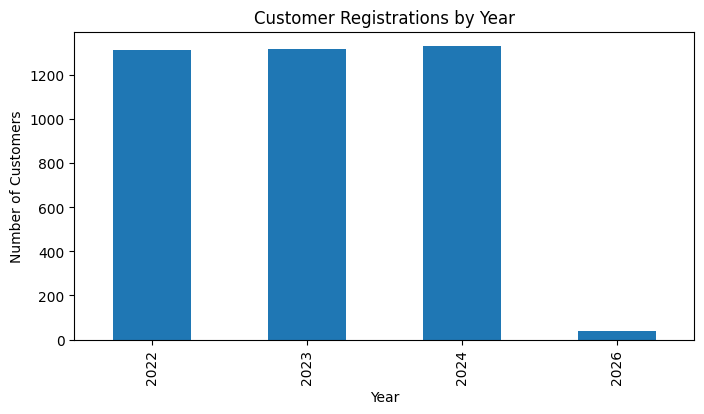

In [19]:
users["reg_date"].dt.year.value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4),
    title="Customer Registrations by Year"
)

plt.xlabel("Year")
plt.ylabel("Number of Customers")
plt.show()

### Interpretation

The `reg_date` variable was successfully converted to the `datetime` format. Most customer registration dates fall between **2022 and 2024**, which is consistent with the expected analysis period.

However, **40 records contain the year 2026**, which exceeds the maximum year supported by the dataset (2024). These values are considered invalid future dates and most likely result from data entry or processing errors.

To preserve the integrity of the analysis, these dates should be investigated and, if they cannot be corrected, converted to `NaT` so they are excluded from time-based analyses.
### Conclusion

The date validation process identified a data quality issue affecting the `reg_date` variable. While the majority of records fall within the expected time frame, **40 future dates (2026)** were detected.

These records should not be used in temporal analyses unless they can be corrected. Converting them to `NaT` is an appropriate strategy because it preserves the remaining data while preventing inaccurate conclusions based on invalid dates.

In [20]:
#  `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

,count
date,
2024.0,39950
NaN,50


# 🧹 Correcting Sentinel Values and Invalid Dates

After identifying data quality issues during the exploration stage, the necessary cleaning rules are applied to improve the consistency and reliability of the datasets.

The following corrections will be performed:

- Replace the invalid age sentinel (`-999`) with the median age.
- Replace the placeholder value (`"?"`) in the `city` column with missing values (`pd.NA`).
- Replace registration dates beyond the analysis period (2024) with `NaT`.

In [21]:
# Replace sentinel value (-999) with the median age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


### Age Cleaning

The value **`-999`** was identified as an invalid placeholder rather than a legitimate age.

Instead of removing affected records, the sentinel value was replaced with the **median age**, which is a robust measure of central tendency and is less sensitive to extreme values than the mean.

This approach preserves all customer records while minimizing the impact of invalid data on subsequent analyses.

In [22]:
# Replace "?" with missing values
users['city'] = users['city'].replace('?', pd.NA)

(users['city'].value_counts(dropna=False))

,count
city,
Bogotá,808
CDMX,730
Medellín,616
NaN,469
GDL,450
Cali,424
MTY,407
<NA>,96


### City Cleaning

The placeholder value **`"?"`** does not represent a valid city and was treated as a sentinel value.

Replacing it with **`pd.NA`** standardizes the representation of missing information, making future analyses and data processing more consistent.

In [23]:
# Replace future dates with NaT
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

,count
reg_date,
2022.0,1314
2023.0,1316
2024.0,1330
NaN,40


### Registration Date Cleaning

Customer registration dates beyond **2024** are outside the valid analysis period and were considered invalid.

These future dates were replaced with **`NaT`** (Not a Time), preventing inaccurate results in any subsequent time-based analysis while preserving the remaining customer information.

# 🧹 Missing Values Assessment

Before deciding how to handle the missing values in the `duration` and `length` variables, it is necessary to determine whether they occur randomly or are related to another variable in the dataset.

To evaluate this, a cross-tabulation is performed between the service `type` and the presence of missing values.

If the missing values are associated with the type of service, they should be preserved because they represent the natural structure of the data rather than data quality issues.

In [24]:
# Verify MAR for duration
pd.crosstab(usage['type'], usage['duration'].isna())

duration,False,True
type,,
call,17908,0
text,16,22076


In [25]:
# Verify MAR for  length
pd.crosstab(usage['type'], usage['length'].isna())

length,False,True
type,,
call,12,17896
text,22092,0


### Interpretation

The cross-tabulation confirms that the missing values are **not random**. Instead, they are directly associated with the service type.

#### `duration`

The `duration` variable is complete for almost all **call** records (17,908 valid values) and is missing for nearly all **text** records (22,076 missing values, with only 16 non-missing observations).

This indicates that call duration is only meaningful for voice calls and is generally not applicable to text messages.

#### `length`

Similarly, the `length` variable is complete for all **text** records (22,092 valid values) and missing for almost all **call** records (17,896 missing values, with only 12 non-missing observations).

This suggests that message length is only relevant for text messages and does not apply to voice calls.
### Conclusion

The analysis confirms that the missing values in both `duration` and `length` are **structural missing values** rather than missing data caused by collection errors.

Their absence is fully explained by the `type` variable:

- **`duration`** is only applicable to voice calls.
- **`length`** is only applicable to text messages.

Therefore, these missing values **should not be imputed or removed**, as doing so would introduce artificial information and could bias the analysis.

The variables will remain unchanged for the remainder of the project.


# 📊 User Usage Aggregation

The `usage` dataset stores one record for each customer activity (phone call or text message). To analyze customer behavior at the user level, these transactional records must be summarized into customer-level metrics.

The following usage indicators are calculated for each customer:

- Total number of text messages (`cant_mensajes`)
- Total number of phone calls (`cant_llamadas`)
- Total call duration in minutes (`cant_minutos_llamada`)

These aggregated metrics provide a concise representation of each customer's historical usage and will later be combined with demographic and subscription information from the `users` dataset.

In [26]:
# Create helper variables
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Aggregate usage metrics by customer
usage_agg = (
    usage
    .groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)

usage_agg.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [27]:
# Merge customer information with aggregated usage metrics
user_profile = users.merge(usage_agg, on="user_id", how="left")
("Customer profile shape:", user_profile.shape)
("Unique customers:", user_profile["user_id"].nunique())
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### Interpretation

The usage records were successfully aggregated at the customer level, converting thousands of individual service events into meaningful behavioral metrics.

The resulting dataset now contains one record per customer with:

- Total number of text messages.
- Total number of phone calls.
- Total call duration.

After merging these metrics with the customer information, a comprehensive analytical dataset was created. This consolidated dataset enables customer segmentation, usage pattern analysis, and plan comparison in the following stages of the project.
### Conclusion

The aggregation process transformed transactional usage records into customer-level indicators, creating a unified analytical dataset.

This new dataset combines demographic information, subscription plans, and historical service usage, providing the foundation for the exploratory analysis and the identification of customer behavior patterns.

# 📊 Customer Profile Summary Statistics

After creating the customer-level analytical dataset, the next step is to examine the overall characteristics of the customers.

This analysis provides a statistical summary of the numerical variables and evaluates the distribution of subscription plans.

The objective is to identify:

- Typical customer behavior.
- Data dispersion.
- Potential extreme values.
- The balance between subscription plans.

In [28]:
# Summary statistics for numerical variables
(user_profile.describe())

,user_id,age,reg_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3960,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,2023-07-03 21:39:41.095273728,5.524381,4.478120,23.317054
min,10000.000000,18.000000,2022-01-01 00:00:00,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022-10-02 20:17:11.657914368,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,2023-07-04 10:00:05.401350400,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,2024-04-03 04:00:05.401350400,7.000000,6.000000,31.415000
max,13999.000000,79.000000,2024-12-31 00:00:00,17.000000,15.000000,155.690000
std,1154.844867,17.689919,NaN,2.358416,2.144238,18.168095


In [29]:
# plan disribution
(user_profile["plan"].value_counts(normalize=True) * 100)


,proportion
plan,
Basico,64.875
Premium,35.125


### Conclusion

The customer profile summary reveals substantial variation in service usage across the customer base, suggesting the existence of different customer segments.

The distribution of subscription plans provides important context for future comparisons, particularly when evaluating differences in customer behavior, service consumption, and churn rates between Basic and Premium users.

# 📊 Customer Age Distribution by Subscription Plan

Understanding the age distribution of customers helps identify whether specific age groups are associated with different subscription plans.

The histogram compares the age distribution of customers subscribed to the Basic and Premium plans, allowing us to evaluate differences in customer demographics and identify potential segmentation opportunities.

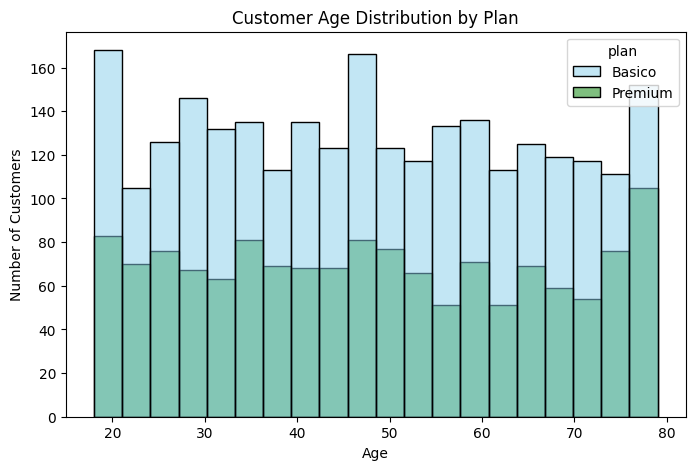

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Customer Age Distribution by Plan")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### Interpretation

The age distribution is relatively similar for customers subscribed to both plans, indicating that age does not appear to be a determining factor in plan selection.

The **Basic** plan consistently includes a larger number of customers across most age groups, which is expected given its higher overall market share.

No age group shows a clear preference for either subscription plan, suggesting that customer age alone is unlikely to explain differences in plan adoption.
### Distribution Shape

The age distribution appears approximately **symmetric**, with no pronounced skewness toward younger or older customers.

No evidence of strong asymmetry or multiple peaks was observed.

### Business Insight

Since both subscription plans exhibit similar age distributions, customer age alone is unlikely to be an effective variable for marketing segmentation or plan recommendation.

Future analyses should focus on behavioral variables such as call frequency, message volume, and total call duration, which are more likely to differentiate customer profiles.

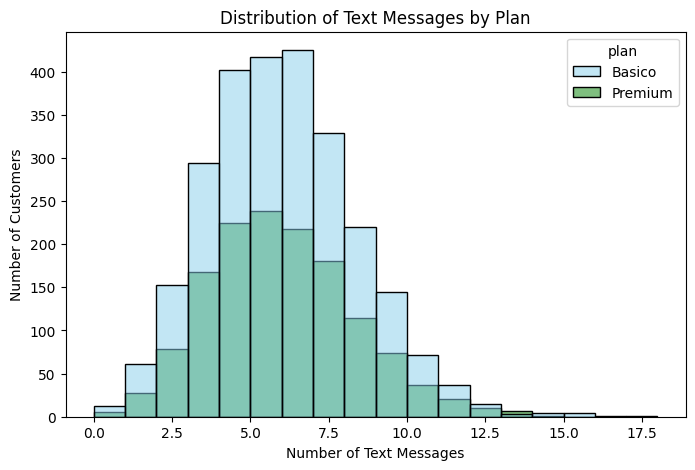

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=range(
        int(user_profile["cant_mensajes"].min()),
        int(user_profile["cant_mensajes"].max()) + 2
    ),
    palette=["skyblue", "green"]
)

plt.title("Distribution of Text Messages by Plan")
plt.xlabel("Number of Text Messages")
plt.ylabel("Number of Customers")
plt.show()

### 💡 Insights

Most customers send between **3 and 8 text messages**, regardless of their subscription plan. The **Basic** plan has a higher number of customers across nearly all message ranges, which is consistent with its larger customer base.

Both plans exhibit very similar messaging behavior, suggesting that the subscription plan does not significantly influence the number of text messages sent.

The distribution is **slightly right-skewed**, indicating that while most customers send relatively few messages, a small number of users have substantially higher messaging activity. These observations may represent potential outliers and will be evaluated in the outlier analysis.


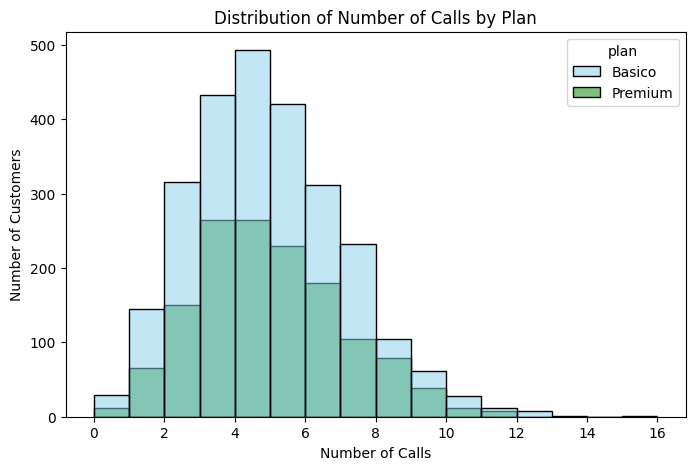

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=range(
        int(user_profile["cant_llamadas"].min()),
        int(user_profile["cant_llamadas"].max()) + 2
    )
)

plt.title("Distribution of Number of Calls by Plan")
plt.xlabel("Number of Calls")
plt.ylabel("Number of Customers")

plt.show()

### 💡 Insights

Most customers make between **3 and 7 phone calls**, regardless of their subscription plan. The **Basic** plan shows a higher number of customers across all call frequency ranges, reflecting its larger customer base rather than a different calling behavior.

Both subscription plans exhibit a very similar distribution of phone calls, indicating that the type of plan does not appear to significantly influence the number of calls made.

The distribution is **right-skewed (positively skewed)**, as most customers make relatively few calls while a small number of users make considerably more calls. These observations may represent potential outliers, which will be confirmed during the outlier analysis.

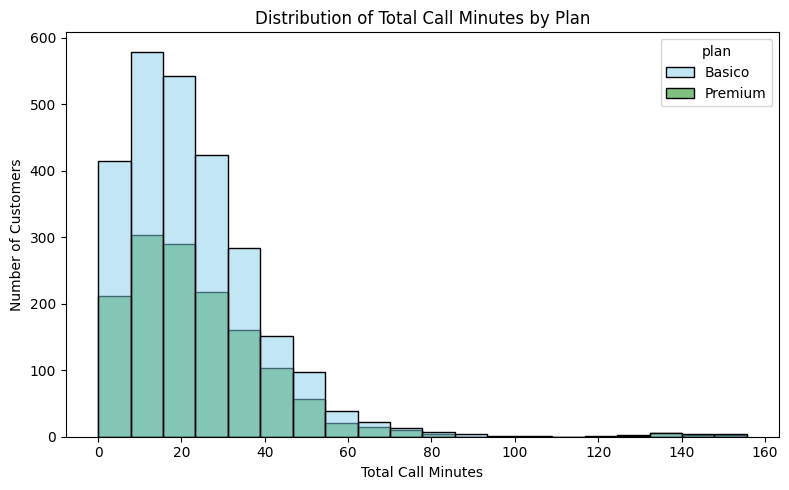

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribution of Total Call Minutes by Plan")
plt.xlabel("Total Call Minutes")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


### 💡 Insights

Most customers accumulate between **5 and 35 total call minutes**, regardless of their subscription plan. The **Basic** plan contains a larger number of customers throughout the distribution, reflecting its higher representation in the customer base.

Both subscription plans exhibit a similar overall pattern of call duration, suggesting that the subscription type alone does not substantially affect the total number of call minutes.

The distribution is **strongly right-skewed**, with a small number of customers accumulating exceptionally high call durations (above 100 minutes). These observations indicate the presence of potential high-usage customers, which will be evaluated further during the outlier analysis.

# 📦 Outlier Detection

Outlier detection is an important step in exploratory data analysis because extreme observations can influence summary statistics, visualizations, and model performance.

To identify potential outliers, boxplots are used for the main customer and usage variables:

- **Age**
- **Number of text messages**
- **Number of phone calls**
- **Total call minutes**

The boxplots display the median, interquartile range (IQR), and observations that fall outside the typical range.

It is important to note that, in the context of a telecommunications company, unusually high service usage does not necessarily indicate erroneous data. These observations may represent customers with intensive service consumption. Therefore, any detected outliers will be evaluated using both statistical criteria (IQR) and business context before deciding whether data cleaning is necessary.

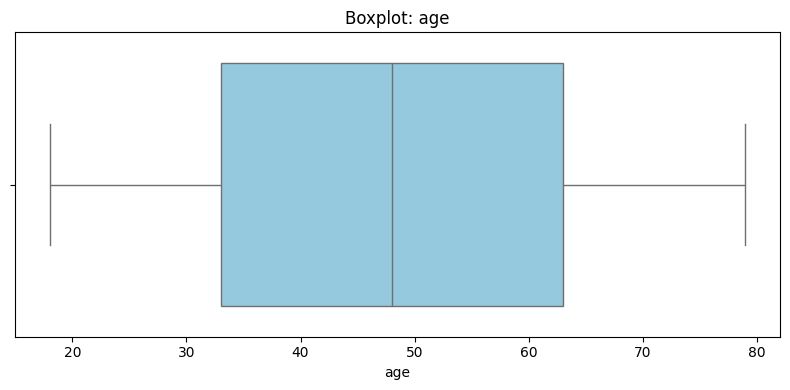

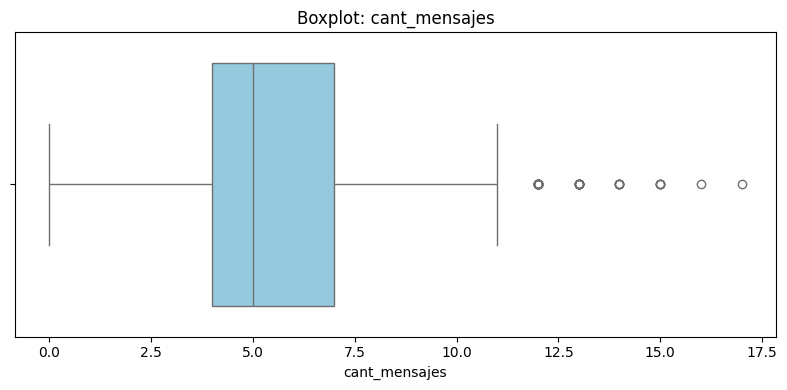

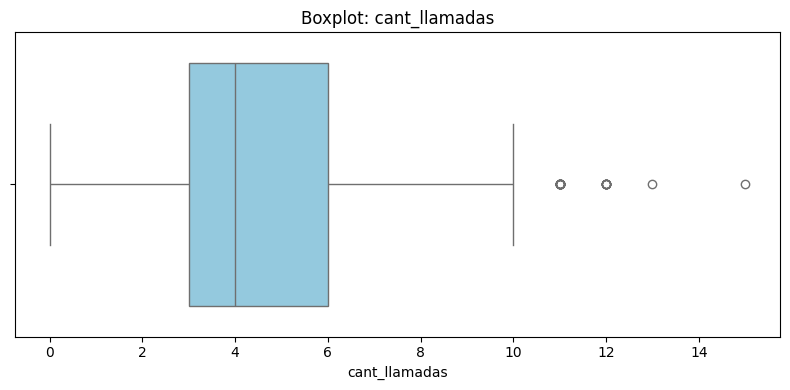

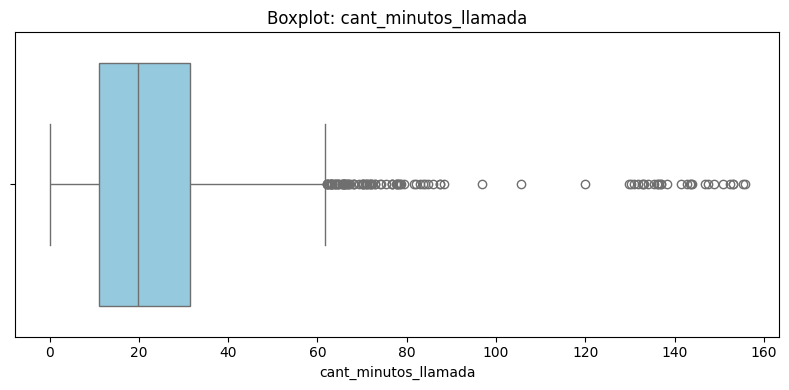

In [43]:
for col in columnas_numericas:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=user_profile[col],
        color="skyblue"
    )

    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

### Insights

- **Age:** No significant outliers were detected after replacing the invalid sentinel value (`-999`). The age distribution appears balanced and suitable for further analysis.

- **cant_mensajes:** A small number of customers send considerably more text messages than the majority. These observations may represent high-usage customers rather than data quality issues.

- **cant_llamadas:** A few customers make a substantially higher number of phone calls compared to the rest of the customer base. These values are isolated and likely reflect natural differences in customer behavior.

- **cant_minutos_llamada:** This variable presents a considerable number of upper outliers. These customers accumulate significantly more call minutes than the majority of users and are likely heavy users rather than erroneous observations.

In [35]:
# Calculate upper IQR limits
columnas_limites =['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    outliers_superiores = user_profile[user_profile[col] > limite_superior]

In [36]:

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


### 💡 Insights

- **cant_mensajes:** The upper outliers were retained because they represent customers with unusually high messaging activity. These observations are plausible within the business context and may correspond to heavy users rather than data quality issues.

- **cant_llamadas:** The upper outliers were also retained, as some customers naturally make a higher number of phone calls than the average user. Removing these observations could eliminate valuable information about customer behavior.

- **cant_minutos_llamada:** Although this variable contains the largest number of upper outliers, these values most likely represent customers with intensive service usage rather than erroneous records. Therefore, the observations will be retained. To reduce the influence of these extreme values, robust statistics such as the median and percentiles will be preferred over the mean when appropriate.

# 👥 Customer Segmentation by Service Usage

Customer segmentation groups users according to their service consumption patterns, making it easier to understand behavioral differences across the customer base.

For this analysis, customers are classified into three usage groups based on the total number of phone calls and text messages:

- **Low Usage:** fewer than 5 calls and fewer than 5 text messages.
- **Medium Usage:** fewer than 10 calls and fewer than 10 text messages.
- **High Usage:** all remaining customers.

This segmentation provides a simple behavioral profile that can support customer retention strategies, personalized marketing campaigns, and future analyses.

In [44]:
# row grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)
# Distribution of customer usage groups
user_profile["grupo_uso"].value_counts()

,count
grupo_uso,
Uso medio,2943
Bajo uso,778
Alto uso,279


In [38]:
# checking
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 💡 Insights

Most customers belong to the **Medium Usage** segment, indicating that the typical customer makes a moderate number of calls and sends a moderate number of text messages.

The **Low Usage** group represents customers with limited interaction with the service, while the **High Usage** segment is considerably smaller and corresponds to customers with intensive service consumption.

This segmentation suggests that the customer base is concentrated around moderate usage levels, with only a small proportion of customers exhibiting high communication activity.

# 👥 Customer Segmentation by Age

Customer age is an important demographic characteristic that can influence service usage patterns and customer preferences.

To facilitate the analysis, customers are grouped into three age categories:

- **Young:** younger than 30 years.
- **Adult:** between 30 and 59 years.
- **Senior Adult:** 60 years or older.

This segmentation will allow future comparisons between age groups and help identify potential differences in customer behavior.

In [45]:
# row grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)
user_profile["grupo_edad"].value_counts()

,count
grupo_edad,
Adulto,2018
Adulto Mayor,1222
Joven,760


In [40]:

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### Business Insight

Age segmentation provides valuable information for customer profiling and marketing strategies.

Different age groups may exhibit different communication habits and service needs, allowing the company to design more personalized plans, promotions, and retention campaigns targeted to each customer segment.

# 📊 Customer Segmentation Visualization

After creating the customer segments, the next step is to visualize their distribution across the customer base.

The charts below illustrate the number of customers in each usage and age group, providing a clearer understanding of the composition of ConnectaTel's customers.

These visualizations help identify the dominant customer segments and provide context for future analyses involving subscription plans, service usage, and churn.

/tmp/ipykernel_1076/216803754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


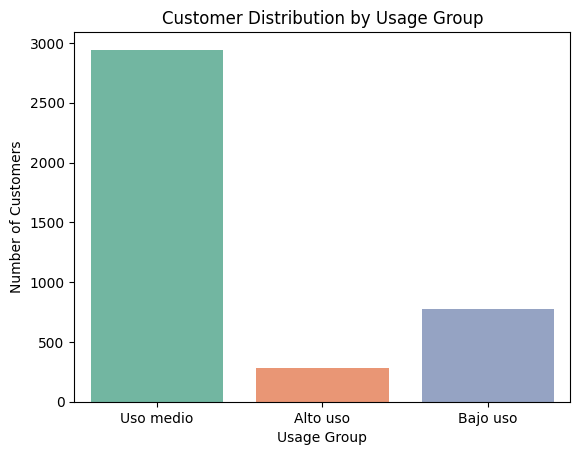

In [48]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette='Set2'
)

plt.title("Customer Distribution by Usage Group")
plt.xlabel("Usage Group")
plt.ylabel("Number of Customers")
plt.show()

/tmp/ipykernel_1076/4240406102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


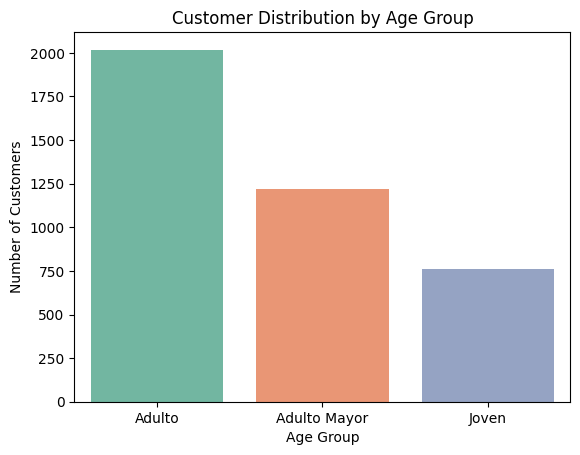

In [49]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette='Set2'
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

### Conclusion

The customer segmentation highlights that the majority of ConnectaTel users are adults with moderate service usage.

These behavioral and demographic segments provide a useful foundation for future analyses, such as comparing subscription plans, identifying high-value customers, and evaluating churn across different customer profiles.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Los datos tenían varios problemas de calidad. En users, la columna city tenía 469 valores nulos, equivalentes al 11.7%, además de 96 valores con "?", que se trataron como datos inválidos. La columna churn_date tenía 3534 nulos, equivalentes al 88.35%, aunque estos probablemente representan usuarios activos. También se detectó el valor -999 en age, que fue corregido usando la mediana. En reg_date aparecieron 40 fechas futuras en 2026, aunque el dataset solo debía llegar hasta 2024, por lo que fueron marcadas como nulas. En usage, date tenía 50 valores nulos, equivalentes al 0.125%. Las columnas duration y length tenían muchos nulos, pero dependían del tipo de uso: duration aplica principalmente a llamadas y length a mensajes, por lo que se dejaron como nulos.


🔍 **Segmentos por Edad**
Se identificaron segmentos por edad, los usuarios se clasificaron como Joven, Adulto y Adulto Mayor.  


📊 **Segmentos por Nivel de Uso**
Adicional se identifican segmentos por uso, se clasificaron como Bajo uso, Uso medio y Alto uso según la cantidad de llamadas y mensajes.


➡️ En general, los usuarios Básico y Premium muestran distribuciones similares, aunque el plan Básico concentra más usuarios porque es el plan con mayor presencia en la base.
Los segmentos más valiosos para ConnectaTel parecen ser los usuarios de Uso medio y Alto uso, especialmente si están en Premium o si tienen un alto volumen de llamadas y mensajes. Estos clientes generan mayor actividad en la red y pueden representar mayor potencial de ingresos, retención y venta de servicios adicionales.

Se encontraron outliers en mensajes, llamadas y especialmente en minutos de llamada. Estos valores extremos parecen representar usuarios intensivos reales, no errores evidentes. Para el negocio, esto implica que existe un grupo pequeño de clientes con consumo muy alto que puede afectar los promedios o mejor visto como una oportunidad comercial importante.


💡 **Recomendaciones**
ConnectaTel podría crear ofertas diferenciadas por comportamiento: planes básicos para Bajo uso, beneficios o paquetes flexibles para Uso medio, y planes Premium o ilimitados para Alto uso. También sería útil diseñar campañas de upgrade para usuarios Básico con alto consumo, porque podrían estar dispuestos a pagar más por mejores beneficios. Finalmente, se recomienda monitorear a los usuarios con uso extremo para evitar problemas de saturación, mejorar la experiencia y ofrecer planes personalizados tambien seria bueno validar si son revendedores o si representa algun tipo de fraude, tener en cuenta usuarios de entros penitenciarios como ejemplo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`